# Эксперимент: popularity tie-break + Spearman связь SID-метрик с RecSys

Два трека в одном ноутбуке.

**Трек A — Popularity tie-break.** Сейчас при коллизии товары получают суффикс `cnt` в порядке индексирования. Заменяем на сортировку по популярности: самый частый товар в кластере → `cnt=0`. GPT2 склонен предсказывать `cnt=0`, поэтому это «маршрутизирует» дефолтный класс на популярный — ожидаем рост Recall@1 / NDCG@1.

**Трек B — Spearman таблица.** Для всех имеющихся чекпоинтов RQ-VAE (5 Improved + 5 Anti) считаем расширенный набор SID-метрик и (если есть GPT2-чекпоинты или мы их обучаем) Recall@K. Затем — Spearman-корреляция между метриками SID и финальным качеством. Это даст «прокси» — какие свойства SID реально предиктивны.

Логика вынесена в `sid_utils.py`. Этот ноутбук — только склейка.

In [1]:
import os, glob, math, sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
from tqdm import tqdm

for p in (r'C:\Users\Admin\Documents\GitHub\claude_plum',
          '/kaggle/input/datasets/qwerte123/hetero-data-updated-diffemb'):
    if os.path.exists(p) and p not in sys.path:
        sys.path.insert(0, p)
import sid_utils
print('sid_utils loaded from', sid_utils.__file__)

sid_utils loaded from /kaggle/input/datasets/qwerte123/hetero-data-updated-diffemb/sid_utils.py


In [2]:
pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 49.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Paths -- mirror GPT2_Rec_Claude.ipynb
KAGGLE_BASE  = '/kaggle/input/datasets/qwerte123/hetero-data-updated-diffemb'
LOCAL_BASE   = r'C:\Users\Admin\Documents\GitHub\claude_plum\data'
BASE         = KAGGLE_BASE if os.path.exists(KAGGLE_BASE) else LOCAL_BASE

DATA_PATH    = os.path.join(BASE, 'heterodata_object12_updated.pt') 
SEQ_PATH     = os.path.join(BASE, 'sequential_data.txt')
CKPT_DIR_IMP = os.path.join(BASE, 'checkpoints_improved') if os.path.exists(LOCAL_BASE) else BASE
CKPT_DIR_ANTI= os.path.join(BASE, 'checkpoints_anti') if os.path.exists(LOCAL_BASE) else BASE

SAVE_DIR = ('/kaggle/working/exp_popularity'
            if os.path.exists('/kaggle')
            else os.path.join(LOCAL_BASE, 'exp_popularity'))
os.makedirs(SAVE_DIR, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

df = torch.load(DATA_PATH, weights_only=False, map_location='cpu')
embeds = df['item'].x
n_items = embeds.shape[0]
print(f'items: {n_items}  embed_dim: {embeds.shape[1]}')

device: cuda
items: 12101  embed_dim: 100


In [4]:
# Item popularity from sequential_data.txt
sequences  = sid_utils.load_sequences(SEQ_PATH)
popularity = sid_utils.compute_item_popularity(sequences, n_items)
print(f'sequences: {len(sequences)}  total interactions: {popularity.sum()}')
print(f'popularity stats: min={popularity.min()}  median={int(np.median(popularity))}  '
      f'max={popularity.max()}  zero={int((popularity==0).sum())}')

sequences: 22363  total interactions: 198502
popularity stats: min=5  median=9  max=431  zero=0


## Архитектура RQ-VAE (копия из GPT2_Rec_Claude)
Мы переиспользуем те же классы для загрузки чекпоинтов.

In [5]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        layers, dims = [], [input_dim] + list(hidden_dims) + [output_dim]
        for i, (a, b) in enumerate(zip(dims[:-1], dims[1:])):
            layers.append(nn.Linear(a, b, bias=True))
            if i < len(dims) - 2:
                layers.append(nn.LayerNorm(b))
                layers.append(nn.ReLU())
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

class EMACodebook(nn.Module):
    def __init__(self, codebook_size, emb_dim, beta=0.25, ema_decay=0.99, epsilon=1e-4):
        super().__init__()
        self.codebook_size = codebook_size; self.beta = beta
        self.ema_decay = ema_decay; self.epsilon = epsilon
        emb = F.normalize(torch.randn(codebook_size, emb_dim), p=2, dim=1)
        self.register_buffer('emb', emb)
        self.register_buffer('ema_count', torch.ones(codebook_size))
        self.register_buffer('ema_weight', emb.clone())
        self.register_buffer('initialized', torch.zeros(1, dtype=torch.bool))
    def forward(self, x):
        x_n = F.normalize(x, p=2, dim=1)
        code_n = F.normalize(self.emb, p=2, dim=1)
        ids = (1.0 - x_n @ code_n.T).argmin(dim=1)
        emb = self.emb[ids]
        return self.beta * F.mse_loss(x, emb.detach()), x + (emb - x).detach(), ids

class _RQVAEBase(nn.Module):
    def __init__(self, inp_size, hidden_sizes, embed_dim, n_layers,
                 codebook_size=256, beta=0.25, gamma=0.1, ema_decay=0.99, **kwargs):
        super().__init__()
        self.n_layers = n_layers
        self.enc = Encoder(inp_size, hidden_sizes, embed_dim)
        self.dec = Encoder(embed_dim, hidden_sizes[::-1], inp_size)
        self.codebooks = nn.ModuleList([
            EMACodebook(codebook_size, embed_dim, beta=beta, ema_decay=ema_decay)
            for _ in range(n_layers)
        ])
    def forward(self, x):
        x_n = F.normalize(x, p=2, dim=1)
        r, sids = self.enc(x_n), []
        for cb in self.codebooks:
            _, emb_st, ids = cb(r)
            r = r - emb_st.detach()
            sids.append(ids)
        return {'sids': sids}

class RQVAE_Improved(_RQVAEBase):
    def __init__(self, *args, temperature=0.07, **kwargs):
        super().__init__(*args, **kwargs); self.temperature = temperature

class RQVAE_AntiContrastive(_RQVAEBase):
    def __init__(self, *args, margin=0.3, **kwargs):
        super().__init__(*args, **kwargs); self.margin = margin

In [6]:
import re

def infer_hidden_sizes(state_dict):
    items = [(k, v) for k, v in state_dict.items()
             if k.startswith('enc.net.') and k.endswith('.weight') and v.dim() == 2]
    items.sort(key=lambda kv: int(re.search(r'enc\.net\.(\d+)\.weight', kv[0]).group(1)))
    return [v.shape[0] for _, v in items][:-1]

def load_rqvae(ckpt_path, model_class, inp_size, device):
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    hp = ckpt['hparams']
    hs = infer_hidden_sizes(ckpt['model_state'])
    kw = {k: hp[k] for k in ('embed_dim','n_layers','codebook_size','beta','gamma','ema_decay') if k in hp}
    if 'temperature' in hp: kw['temperature'] = hp['temperature']
    if 'margin'      in hp: kw['margin']      = hp['margin']
    model = model_class(inp_size=inp_size, hidden_sizes=hs, **kw).to(device)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    return model, hp

# Collect all checkpoints. We will iterate over all of them for the Spearman table.
all_ckpts = []
for p in sorted(glob.glob(os.path.join(CKPT_DIR_IMP,  'rqvae_improved_s*.pt'))):
    all_ckpts.append(('improved', p))
for p in sorted(glob.glob(os.path.join(CKPT_DIR_ANTI, 'rqvae_anti_s*.pt'))):
    all_ckpts.append(('anti', p))
print(f'found {len(all_ckpts)} checkpoints')
for k, p in all_ckpts:
    print(f'  {k:8s}  {os.path.basename(p)}')

found 10 checkpoints
  improved  rqvae_improved_s1.pt
  improved  rqvae_improved_s2.pt
  improved  rqvae_improved_s3.pt
  improved  rqvae_improved_s4.pt
  improved  rqvae_improved_s5.pt
  anti      rqvae_anti_s1.pt
  anti      rqvae_anti_s2.pt
  anti      rqvae_anti_s3.pt
  anti      rqvae_anti_s4.pt
  anti      rqvae_anti_s5.pt


## Трек B (часть 1): SID-метрики для всех чекпоинтов

Для каждого чекпоинта считаем единый вектор SID-метрик: per-level entropy, per-level unique, n_collisions, max_dupe, CFR, embedding-PAS, behavioral-PAS (Jaccard по пользователям), Zipf-alpha, CUR. Потом агрегируем в таблицу.

In [7]:
rows = []
for kind, ckpt_path in all_ckpts:
    cls = RQVAE_Improved if kind == 'improved' else RQVAE_AntiContrastive
    rqvae, hp = load_rqvae(ckpt_path, cls, embeds.shape[1], device)
    metrics = sid_utils.compute_sid_metrics(
        rqvae, embeds, device,
        codebook_size=hp['codebook_size'],
        popularity=popularity,
        sequences=sequences,
    )
    metrics['kind'] = kind
    metrics['ckpt'] = os.path.basename(ckpt_path)
    rows.append(metrics)
    print(f'{kind:8s} {os.path.basename(ckpt_path):28s}  '
          f"CFR={metrics['cfr']:.3f}  H_min={metrics['entropy_min']:.2f}  "
          f"PAS_emb={metrics['pas_emb']:.3f}  PAS_beh={metrics.get('pas_behavioral', float('nan')):.3f}")
    del rqvae
    torch.cuda.empty_cache() if device == 'cuda' else None

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv(os.path.join(SAVE_DIR, 'sid_metrics.csv'), index=False)
metrics_df

improved rqvae_improved_s1.pt          CFR=0.957  H_min=7.38  PAS_emb=0.982  PAS_beh=0.033
improved rqvae_improved_s2.pt          CFR=0.965  H_min=7.62  PAS_emb=0.984  PAS_beh=0.048
improved rqvae_improved_s3.pt          CFR=0.971  H_min=7.73  PAS_emb=0.987  PAS_beh=0.051
improved rqvae_improved_s4.pt          CFR=0.969  H_min=7.63  PAS_emb=0.981  PAS_beh=0.041
improved rqvae_improved_s5.pt          CFR=0.971  H_min=7.73  PAS_emb=0.983  PAS_beh=0.038
anti     rqvae_anti_s1.pt              CFR=0.751  H_min=2.46  PAS_emb=0.907  PAS_beh=0.006
anti     rqvae_anti_s2.pt              CFR=0.808  H_min=2.50  PAS_emb=0.925  PAS_beh=0.008
anti     rqvae_anti_s3.pt              CFR=0.847  H_min=2.48  PAS_emb=0.938  PAS_beh=0.012
anti     rqvae_anti_s4.pt              CFR=0.865  H_min=2.48  PAS_emb=0.942  PAS_beh=0.013
anti     rqvae_anti_s5.pt              CFR=0.852  H_min=2.52  PAS_emb=0.939  PAS_beh=0.013


,n_layers,codebook_size,entropy_l0,entropy_l1,entropy_l2,entropy_l3,unique_l0,unique_l1,unique_l2,unique_l3,...,unique_total_base,n_collisions,max_dupe,cfr,pas_emb,cur_total,zipf_alpha_full,pas_behavioral,kind,ckpt
0,4,256,7.516277,7.384658,7.414833,7.597966,242,254,255,256,...,11580,521,17,0.956946,0.981667,0.000003,0.097131,0.033278,improved,rqvae_improved_s1.pt
1,4,256,7.693713,7.759557,7.616287,7.720314,256,256,256,256,...,11674,427,9,0.964714,0.984328,0.000003,0.085202,0.048274,improved,rqvae_improved_s2.pt
2,4,256,7.732116,7.892258,7.841466,7.830904,256,256,256,256,...,11756,345,11,0.971490,0.986684,0.000003,0.071956,0.051341,improved,rqvae_improved_s3.pt
3,4,256,7.732877,7.748565,7.626672,7.718519,256,256,256,256,...,11725,376,10,0.968928,0.980763,0.000003,0.076860,0.040749,improved,rqvae_improved_s4.pt
4,4,256,7.733860,7.880973,7.840754,7.824129,256,256,256,256,...,11754,347,6,0.971325,0.983277,0.000003,0.073581,0.037636,improved,rqvae_improved_s5.pt
5,4,256,2.464229,6.312356,7.430823,7.621956,7,105,254,256,...,9088,3013,44,0.751012,0.906544,0.000002,0.357856,0.005725,anti,rqvae_anti_s1.pt
6,4,256,2.504016,6.517063,7.307675,7.783539,7,106,255,256,...,9780,2321,20,0.808198,0.924672,0.000002,0.299261,0.008030,anti,rqvae_anti_s2.pt
7,4,256,2.482794,6.501535,7.767701,7.866756,7,106,256,256,...,10247,1854,11,0.846790,0.938453,0.000002,0.254647,0.012495,anti,rqvae_anti_s3.pt
8,4,256,2.478935,6.480696,7.713192,7.856275,7,106,256,256,...,10465,1636,14,0.864805,0.942447,0.000002,0.232338,0.013197,anti,rqvae_anti_s4.pt
9,4,256,2.523952,6.504197,7.711338,7.881159,7,106,256,256,...,10311,1790,21,0.852078,0.939252,0.000002,0.247120,0.013317,anti,rqvae_anti_s5.pt


## Трек B (часть 2): обучаем GPT2Rec на каждом варианте SID

Для Spearman-корреляции нужны парные точки `(SID-метрика, RecSys-метрика)`. Если у вас уже есть результаты Recall/NDCG для всех чекпоинтов — впишите их в `external_recall` ниже и пропустите тренировку. Иначе ниже короткая (15 epochs) тренировка GPT2Rec для каждого чекпоинта.

**Важно:** одинаковый seed, одинаковая архитектура GPT2 — варьируется только источник SID.

In [8]:
# OPTIONAL FAST PATH: если у вас уже есть Recall/NDCG для каких-то чекпоинтов,
# впишите их сюда. Ключ -- basename чекпоинта.
external_recall = {
    # 'rqvae_improved_s5.pt': {'Recall@1': 0.0054, 'Recall@5': 0.0250, 'Recall@10': 0.0459,
    #                          'Recall@20': 0.0762, 'NDCG@10': 0.0218, 'NDCG@20': 0.0295},
    # 'rqvae_anti_s5.pt':     {'Recall@1': 0.0063, 'Recall@5': 0.0210, 'Recall@10': 0.0354,
    #                          'Recall@20': 0.0554, 'NDCG@10': 0.0182, 'NDCG@20': 0.0233},
}
print(f'external recall provided for {len(external_recall)} checkpoints')

external recall provided for 0 checkpoints


In [9]:
# Mini GPT2Rec config -- shorter than the main run, only for ablation
PAD_ID, BOS_ID = 0, 1
MAX_HIST_LEN = 20
D_MODEL, N_HEADS, N_LAYERS_GPT, DROPOUT = 256, 8, 4, 0.1
BATCH_SIZE, LR, WARMUP_STEPS = 256, 1e-3, 500
N_EPOCHS_ABLATION = 15  # short for the Spearman sweep
BEAM_SIZE = 32
EVAL_KS = [1, 5, 10, 20]

# ---- minimal GPT2Rec + dataset (copies from main notebook) ----
class GPT2Rec(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, max_seq_len, n_levels, dropout=0.1):
        super().__init__()
        self.d_model, self.n_levels, self.max_seq_len = d_model, n_levels, max_seq_len
        self.tok_emb = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_emb = nn.Embedding(max_seq_len, d_model)
        self.lvl_emb = nn.Embedding(n_levels, d_model)
        enc = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=4*d_model,
                                         dropout=dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc, num_layers=n_layers)
        self.ln_f = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.tok_emb.weight
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)
                if m.padding_idx is not None: m.weight.data[m.padding_idx].zero_()
    def _level_ids(self, T, dev):
        ids = torch.zeros(T, dtype=torch.long, device=dev)
        for pos in range(1, T): ids[pos] = (pos - 1) % self.n_levels
        return ids.unsqueeze(0)
    def forward(self, x):
        B, T = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0)
        lvl = self._level_ids(T, x.device).expand(B, -1)
        h = self.tok_emb(x) + self.pos_emb(pos) + self.lvl_emb(lvl)
        causal = nn.Transformer.generate_square_subsequent_mask(T, device=x.device)
        pad_m = (x == PAD_ID)
        for layer in self.transformer.layers:
            h = layer(h, src_mask=causal, src_key_padding_mask=pad_m)
            h = h.masked_fill(pad_m.unsqueeze(-1), 0.0)
        if self.transformer.norm is not None: h = self.transformer.norm(h)
        return self.lm_head(self.ln_f(h))

class RecDataset(Dataset):
    def __init__(self, samples, max_hist_len, n_levels, full_supervision, item_to_tokens, history_to_tokens):
        self.samples=samples; self.max_hist_len=max_hist_len; self.n_levels=n_levels
        self.full_supervision=full_supervision
        self.item_to_tokens=item_to_tokens; self.history_to_tokens=history_to_tokens
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        ctx, tgt = self.samples[idx]
        ctx = ctx[-self.max_hist_len:]
        inp = self.history_to_tokens(ctx) + self.item_to_tokens(tgt)
        inp = torch.tensor(inp, dtype=torch.long)
        lbl = inp[1:].clone()
        if not self.full_supervision: lbl[:-self.n_levels] = -100
        lbl = torch.cat([lbl, torch.tensor([-100])])
        return inp, lbl

def collate_fn(batch):
    inps, lbls = zip(*batch)
    M = max(x.shape[0] for x in inps)
    pi, pl = [], []
    for inp, lbl in zip(inps, lbls):
        pad = M - inp.shape[0]
        pi.append(F.pad(inp, (pad, 0), value=PAD_ID))
        pl.append(F.pad(lbl, (pad, 0), value=-100))
    return torch.stack(pi), torch.stack(pl)

@torch.no_grad()
def beam_search(model, ctx_tok, trie, beam_size, device, level_offsets):
    model.eval()
    n_levels = len(level_offsets); ctx = ctx_tok.to(device)
    logits0 = model(ctx.unsqueeze(0))[0, -1, :]
    beams = [(logits0[c + level_offsets[0]].item(), (c,), sub) for c, sub in trie.items()]
    beams.sort(key=lambda x: -x[0]); beams = beams[:beam_size]
    for lvl in range(1, n_levels):
        code_toks = torch.tensor(
            [[codes[l] + level_offsets[l] for l in range(len(codes))] for _, codes, _ in beams],
            device=device)
        batch = torch.cat([ctx.unsqueeze(0).expand(len(beams), -1), code_toks], dim=1)
        logits = model(batch)[:, -1, :]
        new_beams, is_last = [], (lvl == n_levels - 1)
        for i, (score, codes, node) in enumerate(beams):
            for c, child in node.items():
                ns = score + logits[i, c + level_offsets[lvl]].item()
                new_beams.append((ns, child) if is_last else (ns, codes + (c,), child))
        new_beams.sort(key=lambda x: -x[0])
        if is_last: return new_beams
        beams = new_beams[:beam_size]
    return []

def evaluate(samples, model, trie, level_offsets, history_to_tokens, beam_size, ks, device, max_hist_len):
    hits, ndcg, total = defaultdict(int), defaultdict(float), 0
    for ctx, tgt in tqdm(samples, leave=False):
        ctx_tok = torch.tensor(history_to_tokens(ctx[-max_hist_len:]), dtype=torch.long)
        ranked = beam_search(model, ctx_tok, trie, beam_size, device, level_offsets)
        ranked_ids = [iid for _, iid in ranked]
        for k in ks:
            top_k = ranked_ids[:k]
            if tgt in top_k:
                hits[k] += 1; ndcg[k] += 1.0 / math.log2(top_k.index(tgt) + 2)
        total += 1
    return {**{f'Recall@{k}': round(hits[k]/total, 4) for k in ks},
            **{f'NDCG@{k}':   round(ndcg[k]/total, 4) for k in ks}}

In [10]:
# Train/val/test splits -- exactly as in the main notebook
hist = df['user', 'rated', 'item'].history

def make_split(split_key, padded=False):
    item_ids = hist[split_key]['item_ID']; item_next = hist[split_key]['item_ID_next']
    out = []
    for u in range(len(item_next)):
        ctx = [int(x) for x in (item_ids[u].tolist() if padded else item_ids[u]) if int(x) >= 0]
        tgt = int(item_next[u])
        if not ctx or tgt < 0 or tgt >= n_items: continue
        out.append((ctx, tgt))
    return out

samples_train = make_split('train', padded=False)
samples_val   = make_split('valid', padded=True)
samples_test  = make_split('test',  padded=True)
print(f'train={len(samples_train)}  val={len(samples_val)}  test={len(samples_test)}')

train=22363  val=22363  test=22363


In [11]:
def build_pipeline(rqvae, hp, tie_break='count'):
    """Build SID assignment, tokenizer, trie for a single (rqvae, tie_break) combo."""
    base = sid_utils.encode_base_sids(rqvae, embeds, device)
    full, sid2item, max_dupe = sid_utils.assign_sids(
        base, tie_break=tie_break,
        popularity=popularity if tie_break == 'popularity' else None)
    L, K = hp['n_layers'], hp['codebook_size']
    n_levels = L + 1
    lev_off = [2 + l * K for l in range(L)] + [2 + L * K]
    vocab = 2 + L * K + max_dupe
    def item_to_tokens(i):
        sid = full[i]
        return [sid[l] + lev_off[l] for l in range(n_levels)]
    def history_to_tokens(ids):
        toks = [BOS_ID]
        for iid in ids: toks.extend(item_to_tokens(int(iid)))
        return toks
    trie = sid_utils.build_trie(sid2item)
    return dict(full=full, sid2item=sid2item, max_dupe=max_dupe,
                n_levels=n_levels, lev_off=lev_off, vocab=vocab,
                item_to_tokens=item_to_tokens, history_to_tokens=history_to_tokens,
                trie=trie)

def train_and_eval(rqvae, hp, tie_break, n_epochs=N_EPOCHS_ABLATION, seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
    pipe = build_pipeline(rqvae, hp, tie_break=tie_break)
    max_seq = 1 + (MAX_HIST_LEN + 1) * pipe['n_levels']
    ds_tr = RecDataset(samples_train, MAX_HIST_LEN, pipe['n_levels'], True,
                       pipe['item_to_tokens'], pipe['history_to_tokens'])
    ds_va = RecDataset(samples_val,   MAX_HIST_LEN, pipe['n_levels'], False,
                       pipe['item_to_tokens'], pipe['history_to_tokens'])
    dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
    dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

    model = GPT2Rec(pipe['vocab'], D_MODEL, N_HEADS, N_LAYERS_GPT, max_seq, pipe['n_levels'], DROPOUT).to(device)
    opt = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    total = n_epochs * len(dl_tr)
    sch = optim.lr_scheduler.LambdaLR(opt, lambda s: (
        s / max(1, WARMUP_STEPS) if s < WARMUP_STEPS
        else max(0.05, 0.5 * (1.0 + math.cos(math.pi * (s - WARMUP_STEPS) / max(1, total - WARMUP_STEPS))))))

    best_val = float('inf'); best_state = None
    for epoch in range(1, n_epochs + 1):
        model.train(); tr_loss, n = 0.0, 0
        for inp, lbl in dl_tr:
            inp, lbl = inp.to(device), lbl.to(device)
            loss = F.cross_entropy(model(inp).view(-1, pipe['vocab']), lbl.view(-1), ignore_index=-100)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sch.step()
            tr_loss += loss.item(); n += 1
        model.eval(); va, m = 0.0, 0
        with torch.no_grad():
            for inp, lbl in dl_va:
                inp, lbl = inp.to(device), lbl.to(device)
                va += F.cross_entropy(model(inp).view(-1, pipe['vocab']), lbl.view(-1), ignore_index=-100).item(); m += 1
        va /= max(1, m)
        if va < best_val: best_val = va; best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    res = evaluate(samples_test, model, pipe['trie'], pipe['lev_off'],
                   pipe['history_to_tokens'], BEAM_SIZE, EVAL_KS, device, MAX_HIST_LEN)
    res['val_loss_best'] = round(best_val, 4)
    return res

## Трек A: popularity vs count tie-break (один лучший чекпоинт)

Тренируем две GPT2Rec модели на одном и том же RQ-VAE, единственная разница — `tie_break`. Это контролируемый A/B.

In [12]:
# Pick the best Improved checkpoint (last trained session)
best_imp_path = sorted(glob.glob(os.path.join(CKPT_DIR_IMP, 'rqvae_improved_s*.pt')))[-1]
rqvae_best, hp_best = load_rqvae(best_imp_path, RQVAE_Improved, embeds.shape[1], device)
print('Using', os.path.basename(best_imp_path))

results_ab = {}
for tie in ('count', 'popularity'):
    print(f'\n=== tie_break={tie} ===')
    res = train_and_eval(rqvae_best, hp_best, tie_break=tie, seed=0)
    results_ab[tie] = res
    print(res)

ab_df = pd.DataFrame(results_ab).T
ab_df.to_csv(os.path.join(SAVE_DIR, 'tiebreak_ab.csv'))
print('\n=== A/B comparison ===')
print(ab_df)
delta = (ab_df.loc['popularity'] - ab_df.loc['count']).round(4)
print('\nDelta (popularity - count):'); print(delta)

Using rqvae_improved_s5.pt

=== tie_break=count ===


/tmp/ipykernel_57/260723694.py:20: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc, num_layers=n_layers)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:823: UserWarning: Support for mismatched src_key_padding_mask and src_mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


{'Recall@1': 0.0056, 'Recall@5': 0.0262, 'Recall@10': 0.048, 'Recall@20': 0.085, 'NDCG@1': 0.0056, 'NDCG@5': 0.0157, 'NDCG@10': 0.0227, 'NDCG@20': 0.032, 'val_loss_best': 1.5022}

=== tie_break=popularity ===


{'Recall@1': 0.0054, 'Recall@5': 0.0259, 'Recall@10': 0.0468, 'Recall@20': 0.0847, 'NDCG@1': 0.0054, 'NDCG@5': 0.0155, 'NDCG@10': 0.0222, 'NDCG@20': 0.0317, 'val_loss_best': 1.502}

=== A/B comparison ===
            Recall@1  Recall@5  Recall@10  Recall@20  NDCG@1  NDCG@5  NDCG@10  \
count         0.0056    0.0262     0.0480     0.0850  0.0056  0.0157   0.0227   
popularity    0.0054    0.0259     0.0468     0.0847  0.0054  0.0155   0.0222   

            NDCG@20  val_loss_best  
count        0.0320         1.5022  
popularity   0.0317         1.5020  

Delta (popularity - count):
Recall@1        -0.0002
Recall@5        -0.0003
Recall@10       -0.0012
Recall@20       -0.0003
NDCG@1          -0.0002
NDCG@5          -0.0002
NDCG@10         -0.0005
NDCG@20         -0.0003
val_loss_best   -0.0002
dtype: float64


## Трек B (часть 3): SID-метрики vs Recall — Spearman

Прогоняем короткую тренировку GPT2Rec для каждого RQ-VAE чекпоинта (с tie_break='count'), собираем Recall/NDCG. Сливаем с уже посчитанной таблицей SID-метрик и считаем Spearman.

In [13]:
RUN_FULL_SWEEP = True  # set False to use only `external_recall`

rec_rows = []
for kind, ckpt_path in all_ckpts:
    name = os.path.basename(ckpt_path)
    if name in external_recall:
        rec_rows.append({'ckpt': name, **external_recall[name]})
        print(f'{name}: from external_recall')
        continue
    if not RUN_FULL_SWEEP:
        continue
    cls = RQVAE_Improved if kind == 'improved' else RQVAE_AntiContrastive
    rqvae, hp = load_rqvae(ckpt_path, cls, embeds.shape[1], device)
    print(f'\n=== Training GPT2 for {name} ({kind}) ===')
    res = train_and_eval(rqvae, hp, tie_break='count', seed=0)
    res['ckpt'] = name
    rec_rows.append(res)
    print(res)
    del rqvae; torch.cuda.empty_cache() if device == 'cuda' else None

rec_df = pd.DataFrame(rec_rows)
rec_df.to_csv(os.path.join(SAVE_DIR, 'recall_per_ckpt.csv'), index=False)
rec_df

/tmp/ipykernel_57/260723694.py:20: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc, num_layers=n_layers)



=== Training GPT2 for rqvae_improved_s1.pt (improved) ===


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:823: UserWarning: Support for mismatched src_key_padding_mask and src_mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


{'Recall@1': 0.0063, 'Recall@5': 0.0257, 'Recall@10': 0.0459, 'Recall@20': 0.079, 'NDCG@1': 0.0063, 'NDCG@5': 0.016, 'NDCG@10': 0.0225, 'NDCG@20': 0.0308, 'val_loss_best': 1.5083, 'ckpt': 'rqvae_improved_s1.pt'}

=== Training GPT2 for rqvae_improved_s2.pt (improved) ===


{'Recall@1': 0.0075, 'Recall@5': 0.0254, 'Recall@10': 0.0456, 'Recall@20': 0.0813, 'NDCG@1': 0.0075, 'NDCG@5': 0.0163, 'NDCG@10': 0.0227, 'NDCG@20': 0.0317, 'val_loss_best': 1.5135, 'ckpt': 'rqvae_improved_s2.pt'}

=== Training GPT2 for rqvae_improved_s3.pt (improved) ===


...

{'Recall@1': 0.0052, 'Recall@5': 0.0183, 'Recall@10': 0.0323, 'Recall@20': 0.0519, 'NDCG@1': 0.0052, 'NDCG@5': 0.0115, 'NDCG@10': 0.016, 'NDCG@20': 0.0209, 'val_loss_best': 1.6092, 'ckpt': 'rqvae_anti_s1.pt'}

=== Training GPT2 for rqvae_anti_s2.pt (anti) ===


{'Recall@1': 0.0048, 'Recall@5': 0.0207, 'Recall@10': 0.0315, 'Recall@20': 0.0509, 'NDCG@1': 0.0048, 'NDCG@5': 0.0128, 'NDCG@10': 0.0163, 'NDCG@20': 0.0211, 'val_loss_best': 1.6148, 'ckpt': 'rqvae_anti_s2.pt'}

=== Training GPT2 for rqvae_anti_s3.pt (anti) ===


{'Recall@1': 0.0054, 'Recall@5': 0.019, 'Recall@10': 0.0346, 'Recall@20': 0.0539, 'NDCG@1': 0.0054, 'NDCG@5': 0.0122, 'NDCG@10': 0.0172, 'NDCG@20': 0.022, 'val_loss_best': 1.6034, 'ckpt': 'rqvae_anti_s3.pt'}

=== Training GPT2 for rqvae_anti_s4.pt (anti) ===


{'Recall@1': 0.0047, 'Recall@5': 0.0199, 'Recall@10': 0.0335, 'Recall@20': 0.0537, 'NDCG@1': 0.0047, 'NDCG@5': 0.0122, 'NDCG@10': 0.0165, 'NDCG@20': 0.0216, 'val_loss_best': 1.6153, 'ckpt': 'rqvae_anti_s4.pt'}

=== Training GPT2 for rqvae_anti_s5.pt (anti) ===


KeyboardInterrupt: 

In [18]:
rec_df = pd.DataFrame(rec_rows)

In [19]:
# Merge SID metrics with Recall, compute Spearman
merged = metrics_df.merge(rec_df, on='ckpt', how='inner')
print(f'merged rows: {len(merged)}')
merged.to_csv(os.path.join(SAVE_DIR, 'merged.csv'), index=False)

target_keys = [c for c in merged.columns if c.startswith('Recall@') or c.startswith('NDCG@')]
drop_for_corr = ['kind', 'ckpt', 'val_loss_best']
rows_for_corr = merged.drop(columns=[c for c in drop_for_corr if c in merged.columns]).to_dict('records')
spearman = sid_utils.spearman_table(rows_for_corr, target_keys)
spearman.to_csv(os.path.join(SAVE_DIR, 'spearman.csv'))
spearman

merged rows: 9


,Recall@1,Recall@5,Recall@10,Recall@20,NDCG@1,NDCG@5,NDCG@10,NDCG@20,Recall@1_p,Recall@5_p,Recall@10_p,Recall@20_p,NDCG@1_p,NDCG@5_p,NDCG@10_p,NDCG@20_p
sid_metric,,,,,,,,,,,,,,,,
n_layers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
codebook_size,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
entropy_l0,0.700,0.917,0.867,0.900,0.700,0.798,0.862,0.946,0.036,0.001,0.002,0.001,0.036,0.010,0.003,0.000
entropy_l1,0.733,0.933,0.833,0.817,0.733,0.891,0.895,0.895,0.025,0.000,0.005,0.007,0.025,0.001,0.001,0.001
entropy_l2,0.183,0.433,0.650,0.617,0.183,0.252,0.586,0.619,0.637,0.244,0.058,0.077,0.637,0.513,0.097,0.075
entropy_l3,-0.333,-0.050,0.017,0.000,-0.333,-0.151,0.067,0.084,0.381,0.898,0.966,1.000,0.381,0.698,0.864,0.831
unique_l0,0.867,0.867,0.867,0.913,0.867,0.875,0.917,0.917,0.002,0.002,0.002,0.001,0.002,0.002,0.001,0.001
unique_l1,0.825,0.896,0.860,0.904,0.825,0.903,0.944,0.944,0.006,0.001,0.003,0.001,0.006,0.001,0.000,0.000
unique_l2,0.378,0.438,0.568,0.647,0.378,0.442,0.680,0.680,0.315,0.238,0.111,0.059,0.315,0.234,0.044,0.044


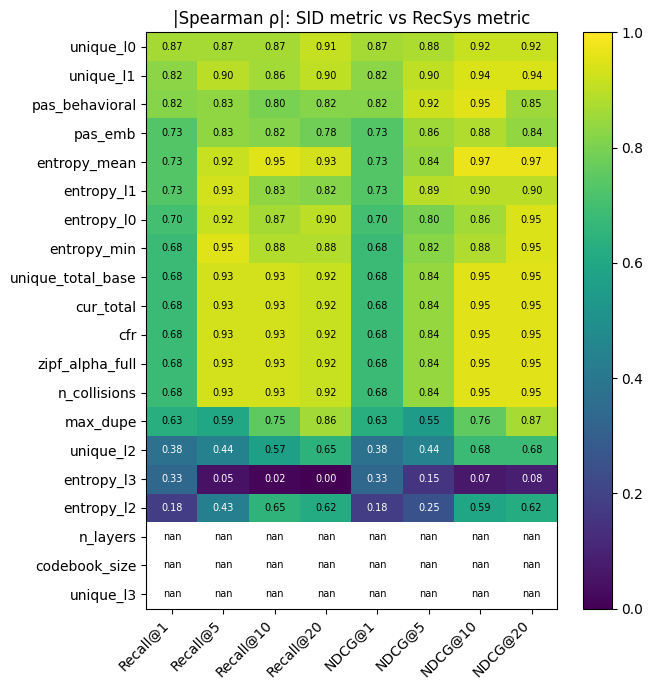

In [ ]:
import matplotlib.pyplot as plt
rho_cols = [c for c in spearman.columns if not c.endswith('_p')]
abs_rho = spearman[rho_cols].abs().sort_values(rho_cols[0], ascending=False)
fig, ax = plt.subplots(figsize=(0.6*len(rho_cols)+2, 0.3*len(abs_rho)+1))
im = ax.imshow(abs_rho.values, aspect='auto', cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(len(rho_cols))); ax.set_xticklabels(rho_cols, rotation=45, ha='right')
ax.set_yticks(range(len(abs_rho))); ax.set_yticklabels(abs_rho.index)
for i in range(len(abs_rho)):
    for j in range(len(rho_cols)):
        ax.text(j, i, f'{abs_rho.values[i,j]:.2f}', ha='center', va='center',
                color='white' if abs_rho.values[i,j] < 0.5 else 'black', fontsize=7)
ax.set_title('|Spearman ρ|: SID metric vs RecSys metric')
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'spearman_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

## Что смотреть в результате

**Трек A (tiebreak A/B):**
- Если `Recall@1` заметно выше у `popularity` — гипотеза подтверждена. Если выросло только @1 а @20 не изменилось — это маршрутизация дефолтного класса, как и предполагалось.
- Если @1 не вырос или упал — GPT2 не предпочитает `cnt=0`, и модель использует disambiguation-уровень иначе. В этом случае стоит попробовать tie-break по близости к центроиду или семантический disambig.

**Трек B (Spearman):**
- Метрика с самым высоким `|ρ|` к Recall@10 — кандидат на «прокси»: можно мерить её без обучения GPT2 при следующих ablation.
- Сравните `pas_emb` (эмбединги) и `pas_behavioral` (поведение пользователей). Ожидание: behavioral сильнее коррелирует с Recall, потому что он ближе к задаче.
- Если `entropy_min` коррелирует с Recall сильнее, чем `cfr` — значит, проблема не в коллизиях, а в коллапсе одного из уровней кодбука.
- 10 точек — статистически слабо (p-value будет высокий). Это первый sanity check; для устойчивого вывода нужно 20+ ablation-точек (варьировать γ, T, n_layers, codebook_size).